In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set overall style for publication-ready plots
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv("Ecommerce_Transactions_Clean.csv")

# Display basic dataset summary
print(f"Total Records: {len(df)}")
df.head()

Total Records: 2545


,Transaction_ID,Customer_ID,Purchase_Date,Product_Category,Product_Name,Quantity,Unit_Price,Total_Amount,Payment_Status,Acquisition_Channel,Customer_Segment,City,State,Gender,Age_Group
0,T000001,C0001,2025-11-13,Electronics,Monitor,3,2398,7194,Success,Organic Search,New,Mumbai,Maharashtra,Male,45-54
1,T000002,C0002,2025-08-16,Books,Novel,1,999,999,Success,Google Ads,New,Kolkata,West Bengal,Male,25-34
2,T000003,C0002,2025-09-30,Accessories,Wallet,3,2999,8997,Success,Google Ads,New,Kolkata,West Bengal,Male,25-34
3,T000004,C0003,2025-07-04,Beauty,Perfume,3,299,897,Success,Instagram,New,Chennai,Tamil Nadu,Male,25-34
4,T000005,C0004,2025-09-13,Electronics,Headphones,1,7498,7498,Success,Facebook Ads,VIP,Delhi,Delhi,Male,45-54


In [3]:
# Convert Purchase_Date column to datetime
df["Purchase_Date"] = pd.to_datetime(df["Purchase_Date"])

# Filter for successful transactions
df_valid = df[df["Payment_Status"] == "Success"].copy()

print(f"Valid Transactions Analyzed: {len(df_valid)}")

Valid Transactions Analyzed: 2338


In [4]:
# 1. Assign Transaction Month
df_valid["TransactionMonth"] = df_valid["Purchase_Date"].dt.to_period("M")

# 2. Assign Cohort Month (First purchase month per customer)
df_valid["CohortMonth"] = df_valid.groupby("Customer_ID")[
    "TransactionMonth"
].transform("min")

# 3. Calculate Cohort Index (Months elapsed since first purchase)
year_diff = (
    df_valid["TransactionMonth"].dt.year - df_valid["CohortMonth"].dt.year
)
month_diff = (
    df_valid["TransactionMonth"].dt.month - df_valid["CohortMonth"].dt.month
)

df_valid["CohortIndex"] = year_diff * 12 + month_diff

df_valid[["Customer_ID", "CohortMonth", "TransactionMonth", "CohortIndex"]].head()

,Customer_ID,CohortMonth,TransactionMonth,CohortIndex
0,C0001,2025-11,2025-11,0
1,C0002,2025-08,2025-08,0
2,C0002,2025-08,2025-09,1
3,C0003,2025-07,2025-07,0
4,C0004,2025-09,2025-09,0


In [11]:
# Create a pivot table: Rows = Cohort Month, Columns = Months Elapsed, Values = Unique Customers
cohort_matrix = (
    df_valid.groupby(["CohortMonth", "CohortIndex"])["Customer_ID"]
    .nunique()
    .unstack()
)

# Extract initial cohort size (Month 0 count)
cohort_sizes = cohort_matrix.iloc[:, 0]

# Compute retention percentage relative to Month 0
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0)

# Format index for visualization labels
retention_matrix.index = retention_matrix.index.astype(str)

retention_matrix.round(3)

CohortIndex,0,1,2,3,4,5,6
CohortMonth,,,,,,,
2025-01,1.0,0.383,0.417,0.167,0.033,NaN,NaN
2025-02,1.0,0.486,0.243,0.176,0.027,0.014,NaN
2025-03,1.0,0.472,0.375,0.208,0.097,0.042,NaN
2025-04,1.0,0.420,0.377,0.101,0.014,0.014,NaN
2025-05,1.0,0.434,0.283,0.151,0.057,NaN,NaN
2025-06,1.0,0.579,0.404,0.281,0.175,0.070,0.018
2025-07,1.0,0.481,0.204,0.130,0.111,0.074,NaN
2025-08,1.0,0.406,0.290,0.130,0.043,0.014,NaN
2025-09,1.0,0.423,0.385,0.192,0.051,0.051,NaN


In [11]:
# Create a pivot table: Rows = Cohort Month, Columns = Months Elapsed, Values = Unique Customers
cohort_matrix = (
    df_valid.groupby(["CohortMonth", "CohortIndex"])["Customer_ID"]
    .nunique()
    .unstack()
)

# Extract initial cohort size (Month 0 count)
cohort_sizes = cohort_matrix.iloc[:, 0]

# Compute retention percentage relative to Month 0
retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0)

# Format index for visualization labels
retention_matrix.index = retention_matrix.index.astype(str)

retention_matrix.round(3)

CohortIndex,0,1,2,3,4,5,6
CohortMonth,,,,,,,
2025-01,1.0,0.383,0.417,0.167,0.033,NaN,NaN
2025-02,1.0,0.486,0.243,0.176,0.027,0.014,NaN
2025-03,1.0,0.472,0.375,0.208,0.097,0.042,NaN
2025-04,1.0,0.420,0.377,0.101,0.014,0.014,NaN
2025-05,1.0,0.434,0.283,0.151,0.057,NaN,NaN
2025-06,1.0,0.579,0.404,0.281,0.175,0.070,0.018
2025-07,1.0,0.481,0.204,0.130,0.111,0.074,NaN
2025-08,1.0,0.406,0.290,0.130,0.043,0.014,NaN
2025-09,1.0,0.423,0.385,0.192,0.051,0.051,NaN


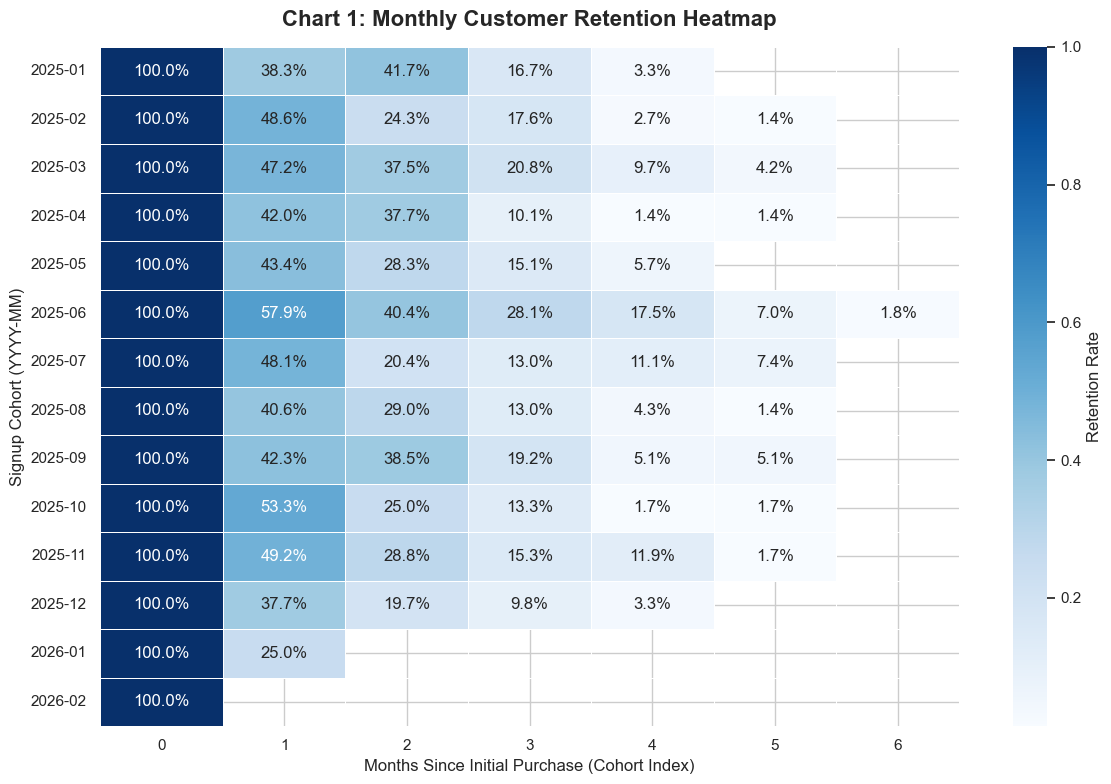

In [13]:
plt.figure(figsize=(12, 8))

# Create the heatmap
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".1%",  # Format as percentage
    cmap="Blues",
    cbar_kws={"label": "Retention Rate"},
    linewidths=0.5,
)

plt.title(
    "Chart 1: Monthly Customer Retention Heatmap",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Months Since Initial Purchase (Cohort Index)", fontsize=12)
plt.ylabel("Signup Cohort (YYYY-MM)", fontsize=12)

plt.tight_layout()
plt.show()

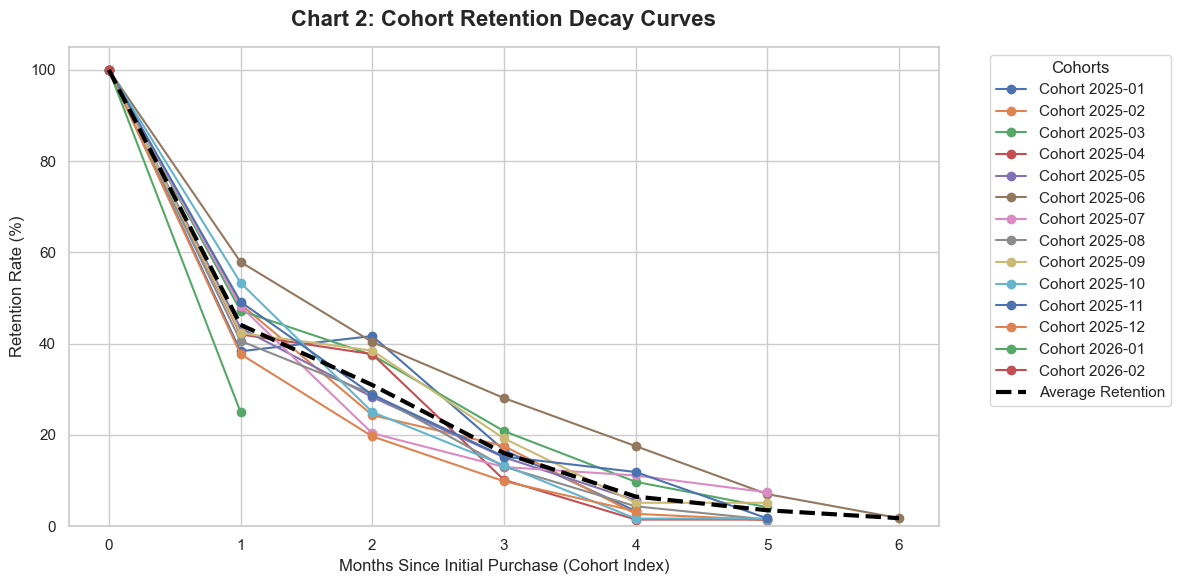

In [14]:
plt.figure(figsize=(12, 6))

# Plot decay line for each individual cohort
for cohort in retention_matrix.index:
    cohort_data = retention_matrix.loc[cohort].dropna()
    plt.plot(
        cohort_data.index,
        cohort_data.values * 100,
        marker="o",
        linewidth=1.5,
        label=f"Cohort {cohort}",
    )

# Plot Average Retention Decay line across all cohorts
avg_retention = retention_matrix.mean(axis=0) * 100
plt.plot(
    avg_retention.index,
    avg_retention.values,
    color="black",
    linewidth=3,
    linestyle="--",
    label="Average Retention",
)

plt.title(
    "Chart 2: Cohort Retention Decay Curves",
    fontsize=16,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Months Since Initial Purchase (Cohort Index)", fontsize=12)
plt.ylabel("Retention Rate (%)", fontsize=12)
plt.xticks(range(0, int(retention_matrix.columns.max()) + 1))
plt.ylim(0, 105)

plt.legend(title="Cohorts", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_21052\2139984388.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


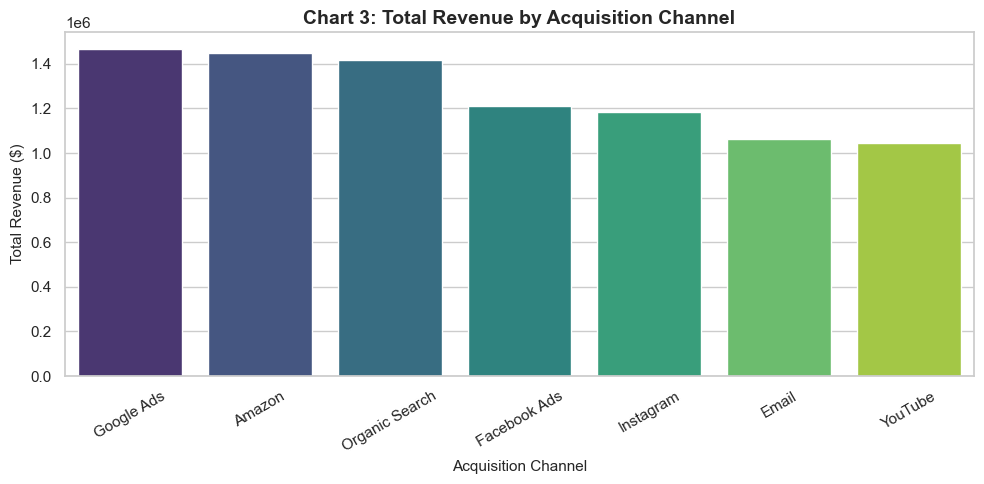

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load data and filter for successful payments
df = pd.read_csv("Ecommerce_Transactions_Clean.csv")
df_valid = df[df["Payment_Status"] == "Success"].copy()

# Aggregate Total Revenue by Channel
channel_rev = (
    df_valid.groupby("Acquisition_Channel")["Total_Amount"]
    .sum()
    .reset_index()
    .sort_values(by="Total_Amount", ascending=False)
)

# Plot Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(
    data=channel_rev,
    x="Acquisition_Channel",
    y="Total_Amount",
    palette="viridis",
)

plt.title(
    "Chart 3: Total Revenue by Acquisition Channel",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Acquisition Channel", fontsize=11)
plt.ylabel("Total Revenue ($)", fontsize=11)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

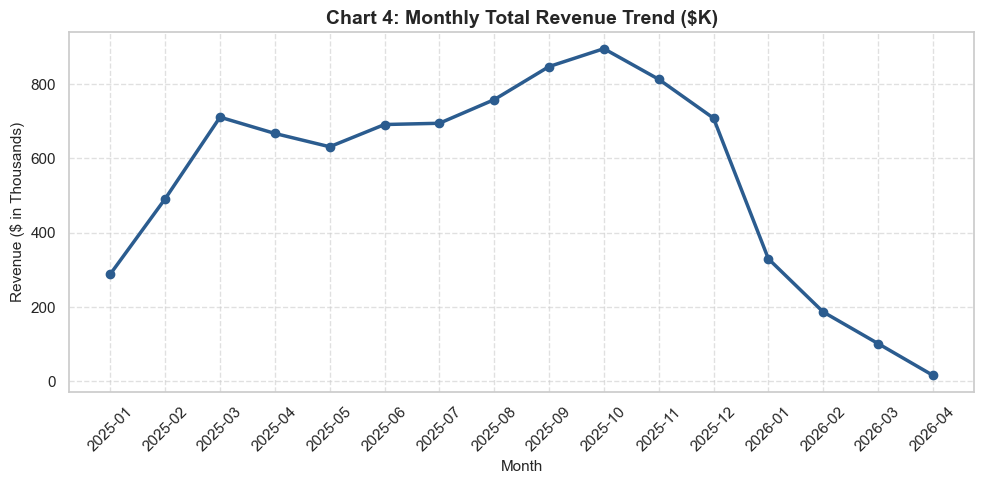

In [17]:
# Convert date and aggregate monthly revenue
df_valid["Purchase_Date"] = pd.to_datetime(df_valid["Purchase_Date"])
df_valid["Month"] = (
    df_valid["Purchase_Date"].dt.to_period("M").astype(str)
)
monthly_rev = (
    df_valid.groupby("Month")["Total_Amount"].sum().reset_index()
)

# Plot Trend Line
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_rev["Month"],
    monthly_rev["Total_Amount"] / 1000,
    marker="o",
    color="#2b5c8f",
    linewidth=2.5,
)

plt.title(
    "Chart 4: Monthly Total Revenue Trend ($K)", fontsize=14, fontweight="bold"
)
plt.xlabel("Month", fontsize=11)
plt.ylabel("Revenue ($ in Thousands)", fontsize=11)
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

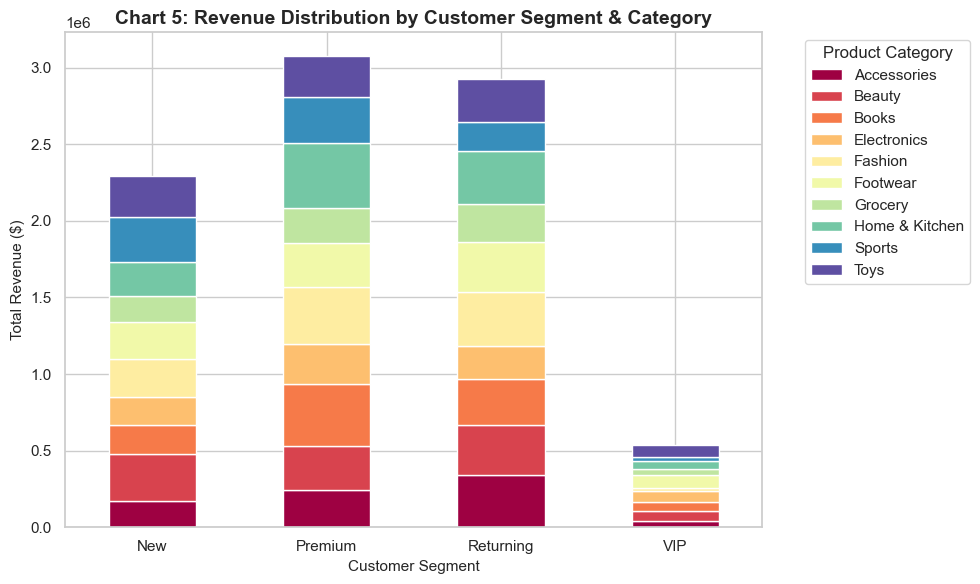

In [18]:
# Pivot data for stacked bar plot
segment_cat = (
    df_valid.groupby(["Customer_Segment", "Product_Category"])["Total_Amount"]
    .sum()
    .unstack()
    .fillna(0)
)

# Plot Stacked Bar Chart
segment_cat.plot(kind="bar", stacked=True, colormap="Spectral", figsize=(10, 6))

plt.title(
    "Chart 5: Revenue Distribution by Customer Segment & Category",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Customer Segment", fontsize=11)
plt.ylabel("Total Revenue ($)", fontsize=11)
plt.xticks(rotation=0)
plt.legend(title="Product Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_21052\3819633475.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=city_rev, x="Total_Amount", y="City", palette="Blues_r")


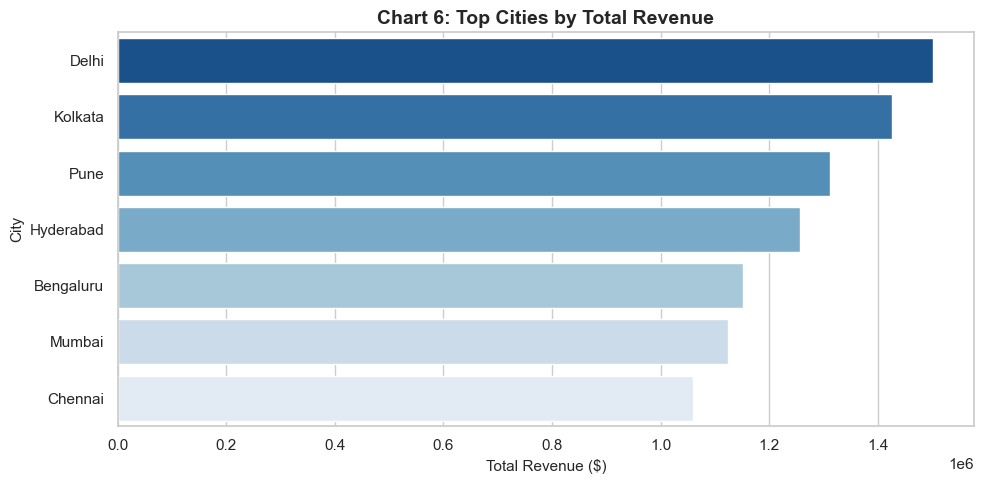

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load and filter data
df = pd.read_csv("Ecommerce_Transactions_Clean.csv")
df_valid = df[df["Payment_Status"] == "Success"].copy()

# Aggregate revenue by city
city_rev = (
    df_valid.groupby("City")["Total_Amount"]
    .sum()
    .reset_index()
    .sort_values(by="Total_Amount", ascending=False)
    .head(10)
)

# Plot Horizontal Bar Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=city_rev, x="Total_Amount", y="City", palette="Blues_r")

plt.title("Chart 6: Top Cities by Total Revenue", fontsize=14, fontweight="bold")
plt.xlabel("Total Revenue ($)", fontsize=11)
plt.ylabel("City", fontsize=11)
plt.tight_layout()
plt.show()